In [1]:
from google.colab import drive
import pandas as pd
# Mount Google Drive to access files
drive.mount("/content/drive", force_remount=True)

# loading datasets from Google Drive
# Make sure the file paths are correct for your files in Google Drive
#regression_df = pd.read_csv("/content/drive/MyDrive/Colab No#tebooks/finance_project/regression_data.csv")

ModuleNotFoundError: No module named 'google.colab'

In [43]:
import pandas as pd
import numpy as np

# Load data
market = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/finance_project/market_data_revised_combined.csv", parse_dates=["date"])
macro_q = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/finance_project/macroeconomic_qrt.csv", parse_dates=["date"])
#macro_a = pd.read_csv("Macroeconomic_Annual.csv")


print(market.head())
print(market.tail())

market = market.reset_index(drop=True)
print(market.head(10))

print(macro_q.head())
print(macro_q.tail())


   company_code       company_name              date  opening    high     low  \
0         22859  ASIAN PAINTS LTD.  03-01-2005 00:00   320.10  325.00  318.60   
1         22859  ASIAN PAINTS LTD.  04-01-2005 00:00   322.00  324.90  320.00   
2         22859  ASIAN PAINTS LTD.  05-01-2005 00:00   324.05  324.95  320.00   
3         22859  ASIAN PAINTS LTD.  06-01-2005 00:00   327.00  327.00  302.55   
4         22859  ASIAN PAINTS LTD.  07-01-2005 00:00   310.00  322.00  309.10   

   closing  trade Volume    Return  
0   319.10         17273 -0.003124  
1   324.05         32240  0.006366  
2   321.85         30500 -0.006789  
3   309.45         38985 -0.053670  
4   320.05         17621  0.032419  
       company_code           company_name              date  opening  \
31495        125123  ULTRATECH CEMENT LTD.  23-02-2026 00:00  12830.0   
31496        125123  ULTRATECH CEMENT LTD.  24-02-2026 00:00  12972.0   
31497        125123  ULTRATECH CEMENT LTD.  25-02-2026 00:00  12961.0   

In [44]:
print("Market Data Nulls:\n", market.isnull().sum())
print("\nMacro Quarterly Nulls:\n", macro_q.isnull().sum())

macro_q[macro_q["Inflation Rate"].isnull()]

Market Data Nulls:
 company_code    0
company_name    0
date            0
opening         0
high            0
low             0
closing         0
trade Volume    0
Return          0
dtype: int64

Macro Quarterly Nulls:
 date               0
GDP Growth Rate    0
Inflation Rate     8
dtype: int64


,date,GDP Growth Rate,Inflation Rate
76,2024-01-01,4.181852,NaN
77,2024-04-01,-7.279660,NaN
78,2024-07-01,-1.427567,NaN
79,2024-10-01,12.751220,NaN
80,2025-01-01,3.813806,NaN
81,2025-04-01,-7.502959,NaN
82,2025-07-01,0.129783,NaN
83,2025-10-01,12.136078,NaN


In [45]:
macro_q = macro_q.sort_values("date")
macro_q["Inflation Rate"] = macro_q["Inflation Rate"].ffill()

print("Market Data Nulls:\n", market.isnull().sum())
print("\nMacro Quarterly Nulls:\n", macro_q.isnull().sum())

macro_q[macro_q["Inflation Rate"].isnull()]

Market Data Nulls:
 company_code    0
company_name    0
date            0
opening         0
high            0
low             0
closing         0
trade Volume    0
Return          0
dtype: int64

Macro Quarterly Nulls:
 date               0
GDP Growth Rate    0
Inflation Rate     0
dtype: int64


,date,GDP Growth Rate,Inflation Rate


In [46]:
print(macro_q.tail(20))

         date  GDP Growth Rate  Inflation Rate
64 2021-01-01         7.777590           -0.39
65 2021-04-01       -15.226512            1.57
66 2021-07-01         9.601132            1.85
67 2021-10-01         5.382518            1.87
68 2022-01-01         6.678430            0.03
69 2022-04-01        -6.134710            2.61
70 2022-07-01        -1.596881            1.43
71 2022-10-01        12.509412            1.51
72 2023-01-01         3.773764            0.38
73 2023-04-01        -7.232969            1.63
74 2023-07-01        -0.622752            2.74
75 2023-10-01        11.937881           -0.02
76 2024-01-01         4.181852           -0.02
77 2024-04-01        -7.279660           -0.02
78 2024-07-01        -1.427567           -0.02
79 2024-10-01        12.751220           -0.02
80 2025-01-01         3.813806           -0.02
81 2025-04-01        -7.502959           -0.02
82 2025-07-01         0.129783           -0.02
83 2025-10-01        12.136078           -0.02


In [55]:
print(market.head())
print(market.tail())

# Convert 'date' column to datetime objects with the specified format
market['date'] = pd.to_datetime(market['date'], format='%d-%m-%Y %H:%M')

# Remove the time component, keeping only the date, and ensuring dtype remains datetime64[ns]
market['date'] = market['date'].dt.normalize()

market = market.sort_values(["date", "company_code"])
macro_q = macro_q.sort_values("date")

print(market.head())
print(market.tail())

   company_code           company_name        date  opening    high      low  \
0         22859      ASIAN PAINTS LTD.  2005-01-03   320.10   325.0   318.60   
1         47858             CIPLA LTD.  2005-01-03   320.00   321.7   316.20   
2         88297      H D F C BANK LTD.  2005-01-03   516.05   527.8   516.05   
3         97066             I T C LTD.  2005-01-03  1318.95  1329.0  1307.00   
4        125123  ULTRATECH CEMENT LTD.  2005-01-03   344.00   348.0   335.00   

   closing  trade Volume    Return  
0   319.10         17273 -0.003124  
1   319.05        862103 -0.002969  
2   525.25        129558  0.017828  
3  1313.15        153779 -0.004397  
4   338.15         73470 -0.017006  
       company_code                    company_name        date  opening  \
31495         47858                      CIPLA LTD.  2026-02-27   1353.0   
31496         88297               H D F C BANK LTD.  2026-02-27    898.6   
31497         97066                      I T C LTD.  2026-02-27    31

In [56]:
print(macro_q.head())
print(macro_q.tail())

market = market.reset_index(drop=True)
print(market.head())

        date  GDP Growth Rate  Inflation Rate
0 2005-01-01         3.916985            0.25
1 2005-04-01        -7.295595            0.57
2 2005-07-01         0.349887            2.21
3 2005-10-01        12.724114            1.91
4 2006-01-01         5.237353           -0.24
         date  GDP Growth Rate  Inflation Rate
79 2024-10-01        12.751220           -0.02
80 2025-01-01         3.813806           -0.02
81 2025-04-01        -7.502959           -0.02
82 2025-07-01         0.129783           -0.02
83 2025-10-01        12.136078           -0.02
   company_code           company_name       date  opening    high      low  \
0         22859      ASIAN PAINTS LTD. 2005-01-03   320.10   325.0   318.60   
1         47858             CIPLA LTD. 2005-01-03   320.00   321.7   316.20   
2         88297      H D F C BANK LTD. 2005-01-03   516.05   527.8   516.05   
3         97066             I T C LTD. 2005-01-03  1318.95  1329.0  1307.00   
4        125123  ULTRATECH CEMENT LTD. 2005-01-

In [57]:
merged = pd.merge_asof(
    market,
    macro_q,
    on="date",
    direction="backward"   # ensures no future data is used
)

In [61]:
print("Merged Data Nulls:\n", merged.isnull().sum())

merged.head(10)
merged.tail(10)

merged = merged.reset_index(drop=True)
print(merged.head(10))
print(merged.tail(10))

Merged Data Nulls:
 company_code       0
company_name       0
date               0
opening            0
high               0
low                0
closing            0
trade Volume       0
Return             0
GDP Growth Rate    0
Inflation Rate     0
dtype: int64
   company_code                    company_name       date  opening    high  \
0         22859               ASIAN PAINTS LTD. 2005-01-03   320.10   325.0   
1         47858                      CIPLA LTD. 2005-01-03   320.00   321.7   
2         88297               H D F C BANK LTD. 2005-01-03   516.05   527.8   
3         97066                      I T C LTD. 2005-01-03  1318.95  1329.0   
4        125123           ULTRATECH CEMENT LTD. 2005-01-03   344.00   348.0   
5        164646  TATA CONSULTANCY SERVICES LTD. 2005-01-03  1335.45  1356.7   
6         22859               ASIAN PAINTS LTD. 2005-01-04   322.00   324.9   
7         47858                      CIPLA LTD. 2005-01-04   321.00   321.0   
8         88297          

In [76]:
print(merged[(merged["company_code"] == 97066) & (merged["date"] == pd.to_datetime('2018-06-04'))])

# Date range preserved?
print(merged["date"].min(), merged["date"].max())

# Row count should match original market data
print(len(market), len(merged))

       company_code company_name       date  opening    high    low  closing  \
19983         97066   I T C LTD. 2018-06-04   270.25  271.95  267.5    268.9   

       trade Volume    Return  GDP Growth Rate  Inflation Rate  
19983       7984112 -0.004995         -3.80419             0.7  
2005-01-03 00:00:00 2026-02-27 00:00:00
31500 31500


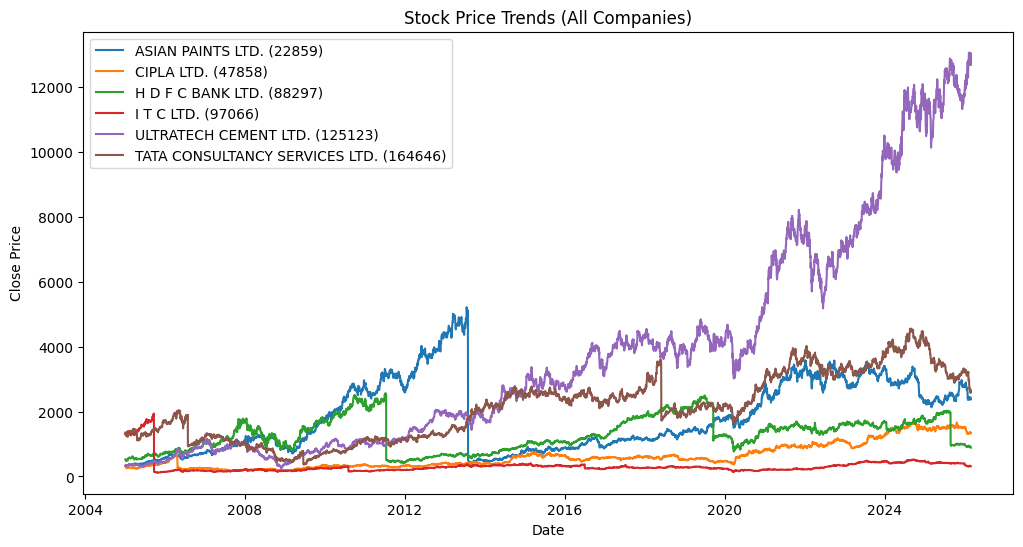

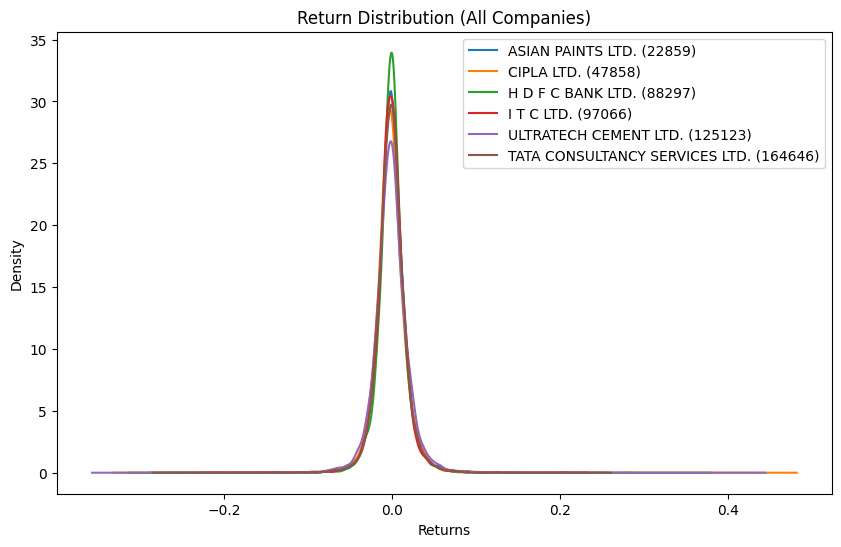

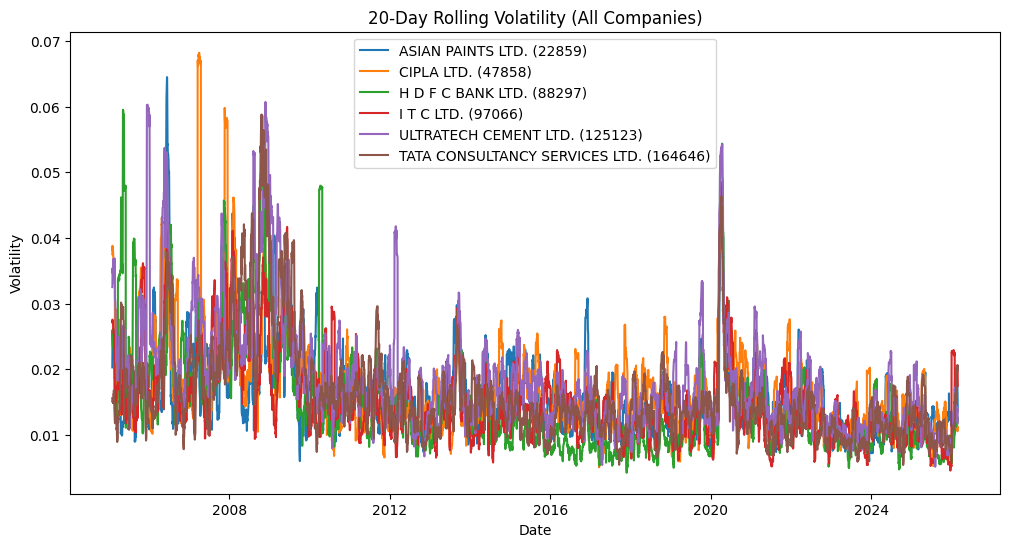

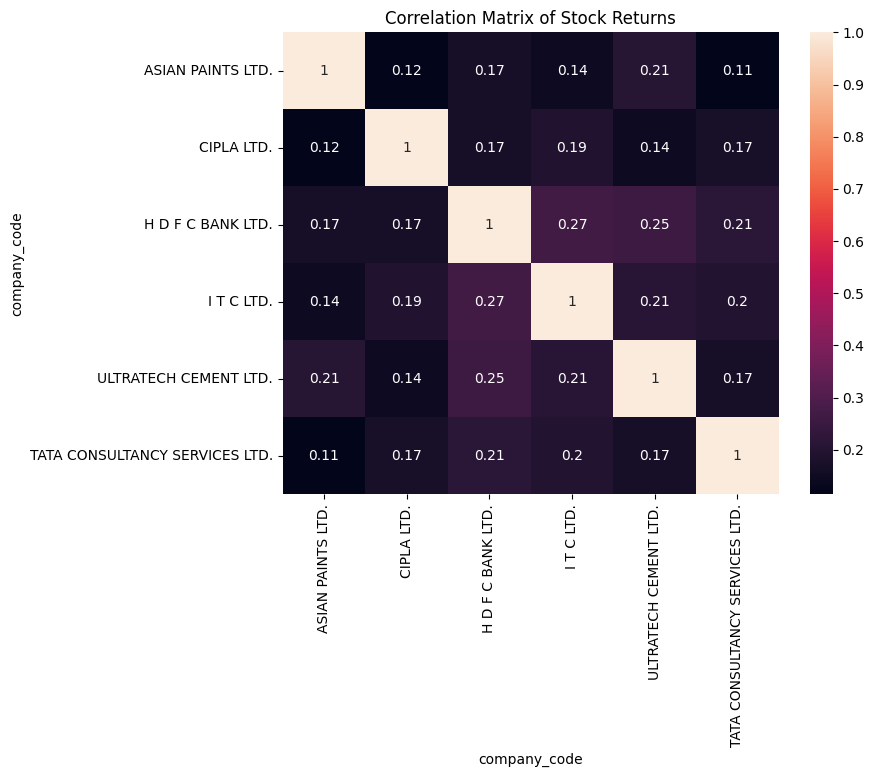

In [84]:
plt.figure(figsize=(12,6))

for company in merged["company_code"].unique():
    subset = merged[merged["company_code"] == company]

    # Extract company name
    name = subset["company_name"].iloc[0]

    plt.plot(subset["date"], subset["closing"],
             label=f"{name} ({company})")

plt.title("Stock Price Trends (All Companies)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()



plt.figure(figsize=(10,6))

for company in merged["company_code"].unique():
    subset = merged[merged["company_code"] == company]

    name = subset["company_name"].iloc[0]

    subset["Return"].plot(kind="kde",
                          label=f"{name} ({company})")

plt.title("Return Distribution (All Companies)")
plt.xlabel("Returns")
plt.legend()
plt.show()


plt.figure(figsize=(12,6))

for company in merged["company_code"].unique():
    subset = merged[merged["company_code"] == company].copy()

    name = subset["company_name"].iloc[0]

    subset["volatility_20"] = subset["Return"].rolling(20).std()

    plt.plot(subset["date"], subset["volatility_20"],
             label=f"{name} ({company})")

plt.title("20-Day Rolling Volatility (All Companies)")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.show()


pivot = merged.pivot(index="date", columns="company_code", values="Return")

# Create mapping: code → name
mapping = merged.drop_duplicates("company_code")[["company_code", "company_name"]]
mapping_dict = dict(zip(mapping["company_code"], mapping["company_name"]))

# Rename columns
pivot.rename(columns=mapping_dict, inplace=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(pivot.corr(), annot=True)
plt.title("Correlation Matrix of Stock Returns")
plt.show()

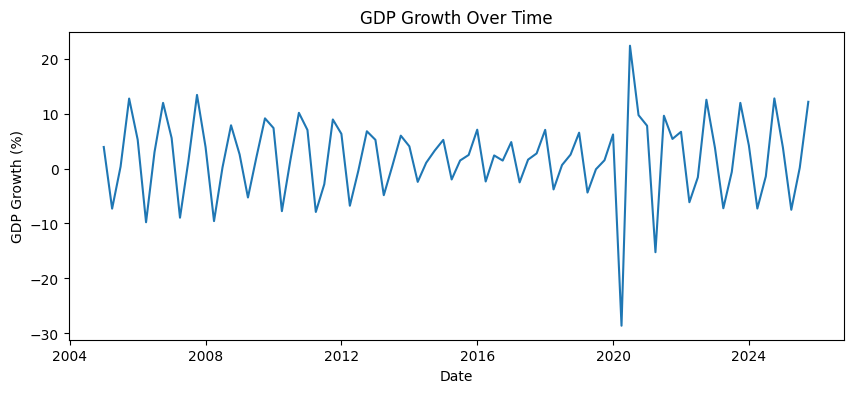

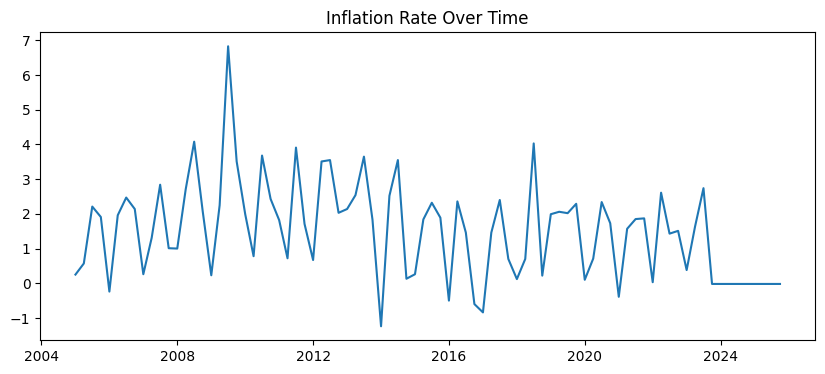

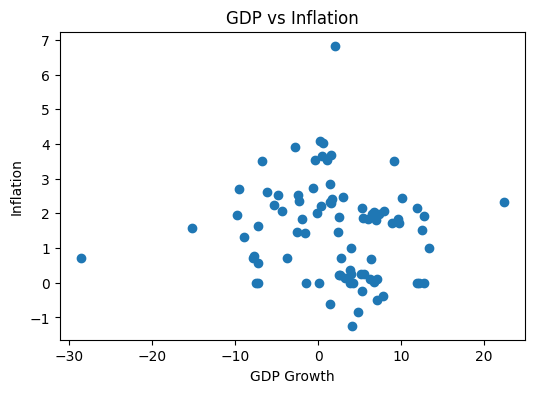

In [89]:
##2. Macroeconomic Visualizations

plt.figure(figsize=(10,4))
plt.plot(macro_q["date"], macro_q["GDP Growth Rate"])
plt.title("GDP Growth Over Time")
plt.xlabel("Date")
plt.ylabel("GDP Growth (%)")
plt.show()


plt.figure(figsize=(10,4))
plt.plot(macro_q["date"], macro_q["Inflation Rate"])
plt.title("Inflation Rate Over Time")
plt.show()


plt.figure(figsize=(6,4))
plt.scatter(macro_q["GDP Growth Rate"], macro_q["Inflation Rate"])
plt.xlabel("GDP Growth")
plt.ylabel("Inflation")
plt.title("GDP vs Inflation")
plt.show()

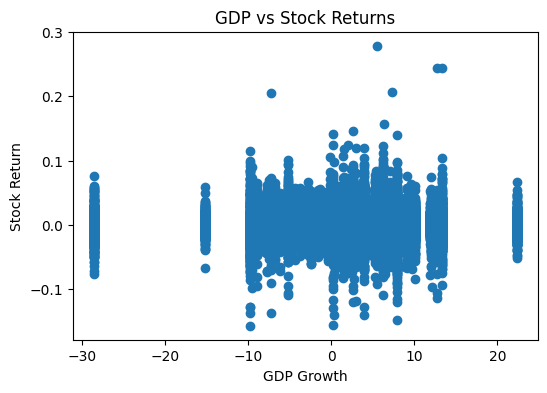

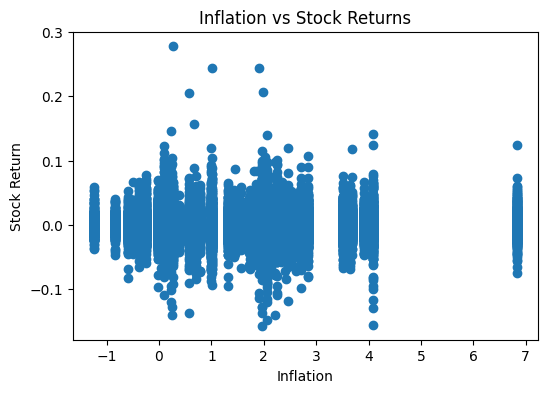

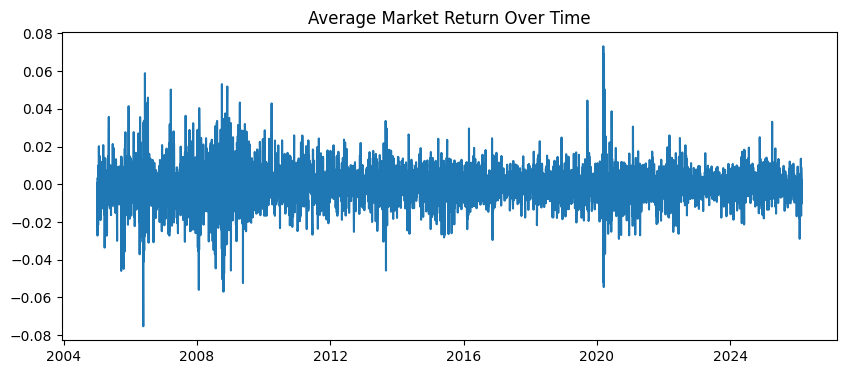

In [90]:
##3. Macro + Market Relationship (VERY IMPORTANT)

plt.figure(figsize=(6,4))
plt.scatter(merged["GDP Growth Rate"], merged["Return"])
plt.xlabel("GDP Growth")
plt.ylabel("Stock Return")
plt.title("GDP vs Stock Returns")
plt.show()


plt.figure(figsize=(6,4))
plt.scatter(merged["Inflation Rate"], merged["Return"])
plt.xlabel("Inflation")
plt.ylabel("Stock Return")
plt.title("Inflation vs Stock Returns")
plt.show()


avg_return = merged.groupby("date")["Return"].mean()

plt.figure(figsize=(10,4))
plt.plot(avg_return)
plt.title("Average Market Return Over Time")
plt.show()

In [108]:
def add_lag_features(df):
    # Lag features capture past returns (short-term memory of stock behavior)

    df["return_lag1"] = df["Return"].shift(1)   # yesterday's return
    df["return_lag5"] = df["Return"].shift(5)   # last week's return
    df["return_lag10"] = df["Return"].shift(10) # ~2 weeks ago

    return df

def add_moving_avg(df):
    # Moving averages smooth price data and capture trend direction

    df["ma_5"] = df["closing"].rolling(5).mean()    # short-term trend
    df["ma_20"] = df["closing"].rolling(20).mean()  # medium-term trend

    # Ratio helps identify bullish/bearish crossover signals
    df["ma_ratio"] = df["ma_5"] / df["ma_20"]

    return df


def add_volatility(df):
    # Rolling standard deviation of returns = volatility (risk)

    df["volatility_5"] = df["Return"].rolling(5).std()    # short-term risk
    df["volatility_20"] = df["Return"].rolling(20).std()  # medium-term risk

    return df



def add_momentum(df):
    # Momentum measures price change over time (strong predictor in finance)

    df["momentum_10"] = df["closing"] / df["closing"].shift(10) - 1  # 10-day momentum
    df["momentum_20"] = df["closing"] / df["closing"].shift(20) - 1  # 20-day momentum

    return df




def add_volume(df):
    # Volume change indicates sudden buying/selling activity

    df["volume_change"] = df["trade Volume"].pct_change()

    return df

def add_macro_features(df):
    # Real economic growth = GDP - inflation
    # Helps capture economic strength adjusted for price changes

    df["real_rate"] = df["GDP Growth Rate"] - df["Inflation Rate"]

    return df

def create_features(df):
    # Ensure data is sorted for rolling calculations
    df = df.sort_values("date")

    # Apply all feature engineering steps
    df = add_lag_features(df)
    df = add_moving_avg(df)
    df = add_volatility(df)
    df = add_momentum(df)
    df = add_volume(df)
    df = add_macro_features(df)

    return df

# Apply feature engineering separately for each company
featured_data = merged.groupby("company_code").apply(create_features).reset_index(drop=True)



# Predict next day's return
featured_data["target_1d"] = (
    featured_data.groupby("company_code")["Return"].shift(-1)
)

# Predict cumulative return over next 5 days (weekly horizon)
featured_data["target_5d"] = (
    featured_data.groupby("company_code")["Return"]
    .rolling(window=5)
    .sum()
    .shift(-5)
    .reset_index(level=0, drop=True)
)

# Check number of missing values in each column
missing_counts = featured_data.isnull().sum()

# Display only columns with missing values
missing_counts[missing_counts > 0]
total_rows_before = len(featured_data)
print("Total rows before dropping:", total_rows_before)

# Rows with at least one missing value
rows_with_na = featured_data.isnull().any(axis=1).sum()
print("Rows with missing values:", rows_with_na)

percentage_loss = (rows_with_na / total_rows_before) * 100
print(f"Percentage of data to be dropped: {percentage_loss:.2f}%")

# Check first few rows where missing values exist
featured_data[featured_data.isnull().any(axis=1)].head(10)

# Remove rows with NaN values created due to lag/rolling/target creation
model_data = featured_data.dropna()

total_rows_after = len(model_data)

print("Rows after dropping:", total_rows_after)
print("Rows dropped:", total_rows_before - total_rows_after)


# Sort by Date first (global time order), then by company
model_data = model_data.sort_values(["date", "company_code"]).reset_index(drop=True)

# Check dataset structure
print(model_data.shape)

# Check columns
print(model_data.columns)

# Preview data
print(model_data.head(10))
print(model_data.tail(10))

print(model_data.isnull().sum())

Total rows before dropping: 31500
Rows with missing values: 150
Percentage of data to be dropped: 0.48%
Rows after dropping: 31350
Rows dropped: 150
(31350, 25)
Index(['company_code', 'company_name', 'date', 'opening', 'high', 'low',
       'closing', 'trade Volume', 'Return', 'GDP Growth Rate',
       'Inflation Rate', 'return_lag1', 'return_lag5', 'return_lag10', 'ma_5',
       'ma_20', 'ma_ratio', 'volatility_5', 'volatility_20', 'momentum_10',
       'momentum_20', 'volume_change', 'real_rate', 'target_1d', 'target_5d'],
      dtype='object')
   company_code                    company_name       date  opening     high  \
0         22859               ASIAN PAINTS LTD. 2005-02-02   330.10   359.90   
1         47858                      CIPLA LTD. 2005-02-02   278.00   286.90   
2         88297               H D F C BANK LTD. 2005-02-02   564.95   564.95   
3         97066                      I T C LTD. 2005-02-02  1351.00  1351.00   
4        125123           ULTRATECH CEMENT LTD.

/tmp/ipykernel_9582/1303839486.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  featured_data = merged.groupby("company_code").apply(create_features).reset_index(drop=True)


In [119]:
# Choose target variable (next-day return)
#target_col = "target_1d"

# (Optional) For weekly model later:
target_col = "target_5d"


# Features to be used in ML model
features = [
    "return_lag1", "return_lag5", "return_lag10",
    "ma_5", "ma_20", "ma_ratio",
    "volatility_5", "volatility_20",
    "momentum_10", "momentum_20",
    "volume_change",
    "GDP Growth Rate", "Inflation Rate", "real_rate"
]


# Determine split date (use last ~20% data as test OR explicitly last 2 years)
split_date = model_data["date"].quantile(0.8)

# Train set → past data
train = model_data[model_data["date"] < split_date].copy()

# Test set → future data
test = model_data[model_data["date"] >= split_date].copy()

# Print dataset sizes
print("Train rows:", len(train))
print("Test rows:", len(test))
print("Split date:", split_date)


from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Initialize model with controlled complexity (to avoid overfitting)
rf_model = RandomForestRegressor(
    n_estimators=200,   # number of decision trees
    max_depth=8,        # limit tree depth for generalization
    random_state=42,
    n_jobs=-1           # use all CPU cores
)

# XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train Random Forest
rf_model.fit(train[features], train[target_col])

# Train XGBoost
xgb_model.fit(train[features], train[target_col])


# Random Forest predictions
test["rf_pred"] = rf_model.predict(test[features])

# XGBoost predictions
test["xgb_pred"] = xgb_model.predict(test[features])

# Preview predictions
test[["date", "company_code", target_col, "rf_pred", "xgb_pred"]].head()

Train rows: 25080
Test rows: 6270
Split date: 2021-12-08 04:48:00


,date,company_code,target_5d,rf_pred,xgb_pred
25080,2021-12-09,22859,0.036040,-0.002972,-0.004303
25081,2021-12-09,47858,-0.028696,-0.005189,-0.008777
25082,2021-12-09,88297,-0.021697,-0.002744,0.002862
25083,2021-12-09,97066,-0.081530,-0.006049,-0.003452
25084,2021-12-09,125123,-0.023743,-0.005740,-0.006350


Task 1: Predicting next day/next week returns


--- Random Forest ---
RMSE: 0.02729380938660138
R2 Score: 0.0011339351274082254
Directional Accuracy: 0.5196172248803828

--- XGBoost ---
RMSE: 0.028558154733613283
R2 Score: -0.09355148605503683
Directional Accuracy: 0.5215311004784688

Model Comparison:

           Model      RMSE  R2 Score  Directional Accuracy
0  Random Forest  0.027294  0.001134              0.519617
1        XGBoost  0.028558 -0.093551              0.521531

Top RF Features:
 volatility_20    0.144933
momentum_20      0.134072
ma_20            0.110344
ma_5             0.096109
volatility_5     0.079717
dtype: float64

Top XGB Features:
 ma_20              0.100853
real_rate          0.090314
volatility_20      0.087244
ma_5               0.084020
GDP Growth Rate    0.081938
dtype: float32


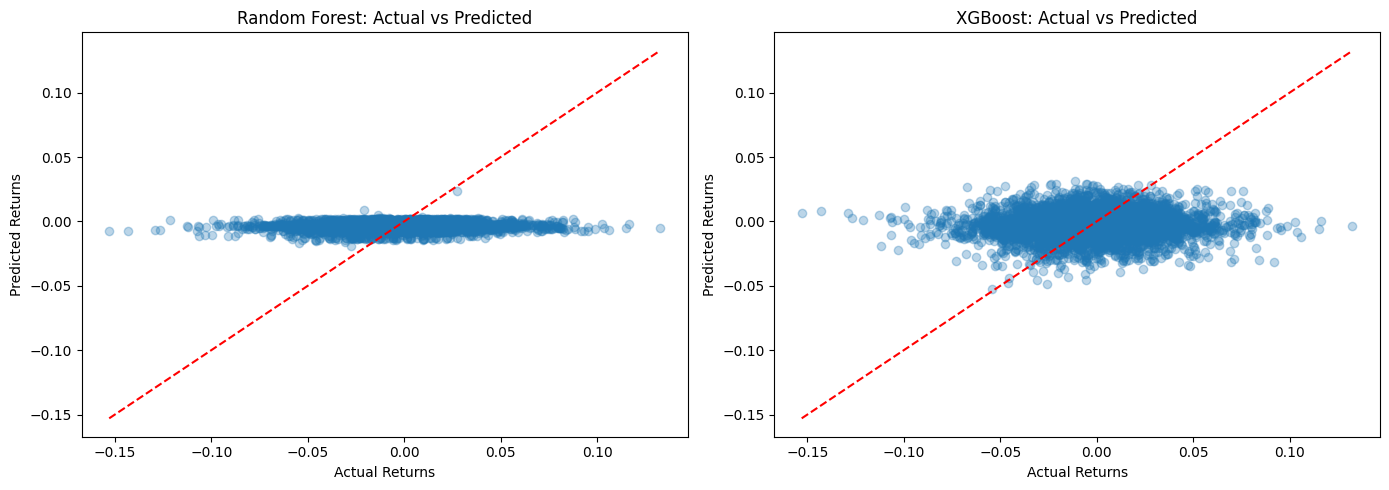

In [120]:
def evaluate_model(y_true, y_pred, model_name):

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # R2 Score
    r2 = r2_score(y_true, y_pred)

    # Directional Accuracy
    actual_dir = np.sign(y_true)
    pred_dir = np.sign(y_pred)
    directional_acc = (actual_dir == pred_dir).mean()

    print(f"\n--- {model_name} ---")
    print("RMSE:", rmse)
    print("R2 Score:", r2)
    print("Directional Accuracy:", directional_acc)

    return rmse, r2, directional_acc

# Random Forest performance
rf_metrics = evaluate_model(
    test[target_col], test["rf_pred"], "Random Forest"
)

# XGBoost performance
xgb_metrics = evaluate_model(
    test[target_col], test["xgb_pred"], "XGBoost"
)

# Create comparison dataframe
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [rf_metrics[0], xgb_metrics[0]],
    "R2 Score": [rf_metrics[1], xgb_metrics[1]],
    "Directional Accuracy": [rf_metrics[2], xgb_metrics[2]]
})

print("\nModel Comparison:\n")
print(comparison)



# Random Forest importance
rf_importance = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

# XGBoost importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

print("\nTop RF Features:\n", rf_importance.head())
print("\nTop XGB Features:\n", xgb_importance.head())



import matplotlib.pyplot as plt

# Create a figure with 2 subplots (side-by-side comparison)
plt.figure(figsize=(14,5))


# -----------------------------------
# 📊 1. Random Forest Plot
# -----------------------------------
plt.subplot(1, 2, 1)  # 1 row, 2 columns, position 1

plt.scatter(
    test[target_col],          # Actual returns
    test["rf_pred"],           # RF predicted returns
    alpha=0.3                  # transparency for better visibility
)

# Perfect prediction line (45-degree reference line)
min_val = min(test[target_col].min(), test["rf_pred"].min())
max_val = max(test[target_col].max(), test["rf_pred"].max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')  # ideal line

plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Random Forest: Actual vs Predicted")


# -----------------------------------
# 📊 2. XGBoost Plot
# -----------------------------------
plt.subplot(1, 2, 2)  # position 2

plt.scatter(
    test[target_col],          # Actual returns
    test["xgb_pred"],          # XGB predicted returns
    alpha=0.3
)

# Same reference line
min_val = min(test[target_col].min(), test["xgb_pred"].min())
max_val = max(test[target_col].max(), test["xgb_pred"].max())

plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("XGBoost: Actual vs Predicted")


# -----------------------------------
# Show plots
# -----------------------------------
plt.tight_layout()
plt.show()

Task 2: Stock ranking

In [125]:
# Use test dataset (already has predictions)
ranking_data = test.copy()


# Rank stocks within each date based on predicted return
ranking_data["rank"] = ranking_data.groupby("date")["rf_pred"] \
                                    .rank(ascending=False, method="first")

# Select top 2 stocks per date
top_n = 2

top_stocks = ranking_data[ranking_data["rank"] <= top_n].copy()

# Check output
top_stocks[["date", "company_code","company_name", "rf_pred", "rank"]].head(10)




,date,company_code,company_name,rf_pred,rank
25080,2021-12-09,22859,ASIAN PAINTS LTD.,-0.002972,2.0
25082,2021-12-09,88297,H D F C BANK LTD.,-0.002744,1.0
25088,2021-12-10,88297,H D F C BANK LTD.,-0.002744,1.0
25091,2021-12-10,164646,TATA CONSULTANCY SERVICES LTD.,-0.002915,2.0
25092,2021-12-13,22859,ASIAN PAINTS LTD.,-0.002933,2.0
25094,2021-12-13,88297,H D F C BANK LTD.,-0.002774,1.0
25098,2021-12-14,22859,ASIAN PAINTS LTD.,-0.002972,2.0
25100,2021-12-14,88297,H D F C BANK LTD.,-0.002774,1.0
25104,2021-12-15,22859,ASIAN PAINTS LTD.,-0.002971,2.0
25106,2021-12-15,88297,H D F C BANK LTD.,-0.002746,1.0


Task 3: Portfolio construction

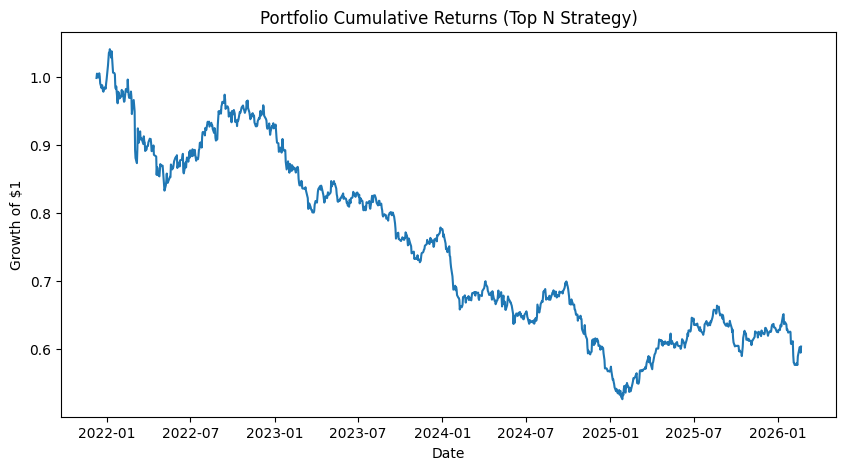

In [127]:
# Assign equal weights to selected stocks per date
top_stocks["weight"] = 1 / top_stocks.groupby("date")["company_code"].transform("count")

# Portfolio return = weight × actual return
top_stocks["portfolio_return"] = top_stocks["weight"] * top_stocks["Return"]

# Aggregate daily portfolio return
portfolio_returns = top_stocks.groupby("date")["portfolio_return"].sum()


# Compute cumulative returns over time
cumulative_returns = (1 + portfolio_returns).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(cumulative_returns)

plt.title("Portfolio Cumulative Returns (Top N Strategy)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.show()


Task 4: Portfolio optimization

   company_code                    company_name    weight
0         22859               ASIAN PAINTS LTD.  0.127405
1         47858                      CIPLA LTD.  0.124129
2         88297               H D F C BANK LTD.  0.121664
3         97066                      I T C LTD.  0.238071
4        125123           ULTRATECH CEMENT LTD.  0.271435
5        164646  TATA CONSULTANCY SERVICES LTD.  0.117296


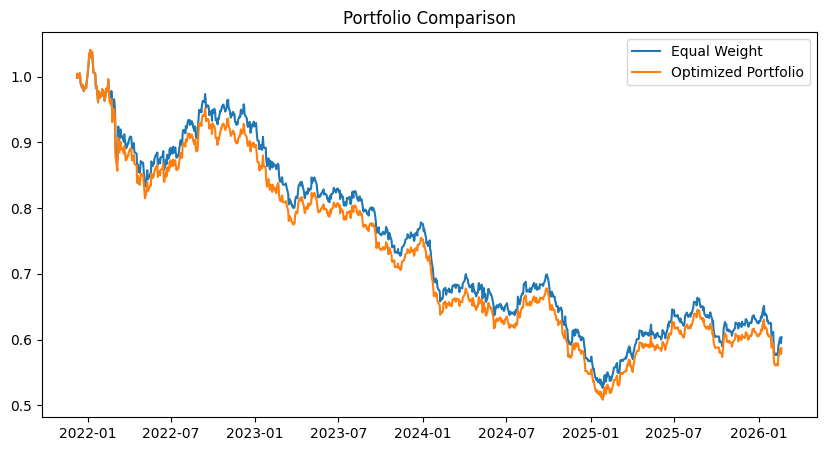

In [131]:
# Pivot returns for covariance calculation
returns_pivot = model_data.pivot(index="date", columns="company_code", values="Return")

# Covariance matrix
cov_matrix = returns_pivot.cov()

# Average predicted returns per stock
expected_returns = ranking_data.groupby("company_code")["rf_pred"].mean()

# Compute risk (volatility)
risk = returns_pivot.std()

# Risk-adjusted score
score = expected_returns / risk

# Normalize weights
weights = score / score.sum()

# Convert weights Series to DataFrame for better display
weights_df = weights.reset_index()
weights_df.columns = ["company_code", "weight"]

# Merge with mapping to get company names
weights_df = pd.merge(weights_df, mapping, on="company_code", how="left")

# Reorder columns for desired output
weights_df = weights_df[["company_code", "company_name", "weight"]]

print(weights_df)

# Map weights to portfolio
top_stocks["opt_weight"] = top_stocks["company_code"].map(weights)

# Normalize weights per date
top_stocks["opt_weight"] = top_stocks.groupby("date")["opt_weight"] \
                                      .transform(lambda x: x / x.sum())

# Compute optimized portfolio returns
top_stocks["opt_portfolio_return"] = top_stocks["opt_weight"] * top_stocks["Return"]

opt_portfolio_returns = top_stocks.groupby("date")["opt_portfolio_return"].sum()

# Cumulative returns
opt_cumulative = (1 + opt_portfolio_returns).cumprod()

plt.figure(figsize=(10,5))

plt.plot(cumulative_returns, label="Equal Weight")
plt.plot(opt_cumulative, label="Optimized Portfolio")

plt.legend()
plt.title("Portfolio Comparison")

plt.show()

Task 5: Backtesting

Backtest period: 2024-02-20 00:00:00 to 2026-02-20 00:00:00
Rows: 2994


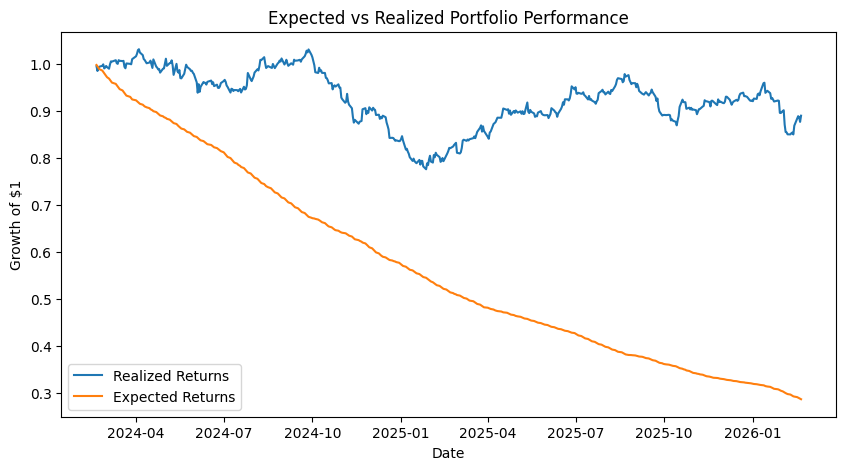

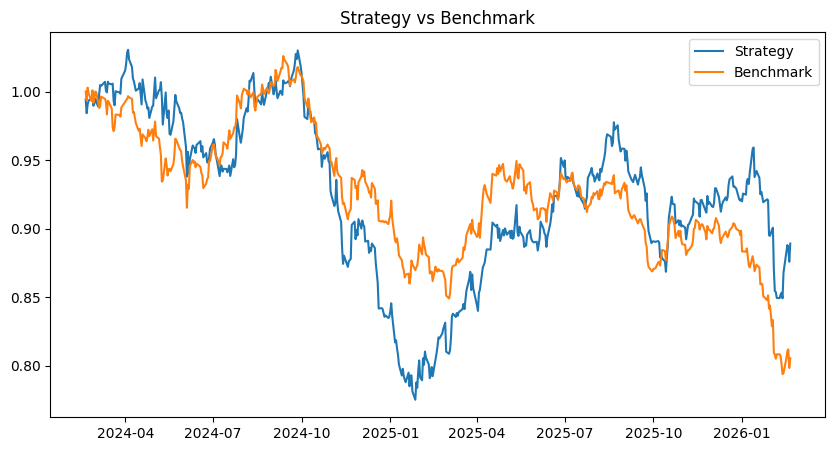

Total Return: -0.11086932807295447
Sharpe Ratio: -0.3553082061894973
Max Drawdown: -0.2478034497596293


In [132]:
# Get last 2 years of data
end_date = model_data["date"].max()
start_date = end_date - pd.DateOffset(years=2)

# Filter test period
backtest_data = test[(test["date"] >= start_date) & (test["date"] <= end_date)].copy()

print("Backtest period:", start_date, "to", end_date)
print("Rows:", len(backtest_data))

# Rank stocks based on predicted returns
backtest_data["rank"] = backtest_data.groupby("date")["rf_pred"] \
                                      .rank(ascending=False, method="first")

# Select top N stocks
top_n = 2
portfolio_bt = backtest_data[backtest_data["rank"] <= top_n].copy()

# Equal allocation across selected stocks
portfolio_bt["weight"] = 1 / portfolio_bt.groupby("date")["company_code"].transform("count")

# Actual realized portfolio return
portfolio_bt["realized_return"] = portfolio_bt["weight"] * portfolio_bt["Return"]

# Daily portfolio return
daily_returns = portfolio_bt.groupby("date")["realized_return"].sum()

# Expected (predicted) portfolio return
portfolio_bt["expected_return"] = portfolio_bt["weight"] * portfolio_bt["rf_pred"]

expected_returns = portfolio_bt.groupby("date")["expected_return"].sum()

# Realized cumulative returns
cum_realized = (1 + daily_returns).cumprod()

# Expected cumulative returns
cum_expected = (1 + expected_returns).cumprod()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(cum_realized, label="Realized Returns")
plt.plot(cum_expected, label="Expected Returns")

plt.legend()
plt.title("Expected vs Realized Portfolio Performance")

plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.show()

# Market benchmark (equal-weight of all stocks)
benchmark = backtest_data.groupby("date")["Return"].mean()

benchmark_cum = (1 + benchmark).cumprod()

# Plot
plt.figure(figsize=(10,5))

plt.plot(cum_realized, label="Strategy")
plt.plot(benchmark_cum, label="Benchmark")

plt.legend()
plt.title("Strategy vs Benchmark")

plt.show()


total_return = cum_realized.iloc[-1] - 1
print("Total Return:", total_return)

import numpy as np

sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
print("Sharpe Ratio:", sharpe)

# Calculate drawdown
rolling_max = cum_realized.cummax()
drawdown = cum_realized / rolling_max - 1

max_drawdown = drawdown.min()
print("Max Drawdown:", max_drawdown)

